In [1]:
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns


In [4]:
import zipfile

In [5]:
with zipfile.ZipFile("titles.csv.zip", "r") as zip_ref:
    zip_ref.extractall()

In [6]:
with zipfile.ZipFile("credits.csv.zip", "r") as zip_ref:
    zip_ref.extractall()

"the first step is to clean and organise the data in a way so it can be used properly for visualisation"

In [7]:
titles_df = pd.read_csv("titles.csv")
credits_df = pd.read_csv("credits.csv")

In [8]:
print(credits_df.head())

   person_id       id           name      character   role
0      59401  ts20945     Joe Besser            Joe  ACTOR
1      31460  ts20945     Moe Howard            Moe  ACTOR
2      31461  ts20945     Larry Fine          Larry  ACTOR
3      21174  tm19248  Buster Keaton    Johnny Gray  ACTOR
4      28713  tm19248    Marion Mack  Annabelle Lee  ACTOR


In [9]:
titles_df.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6
1,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0
2,tm82253,The Best Years of Our Lives,MOVIE,It's the hope that sustains the spirit of ever...,1946,NaN,171,"['romance', 'war', 'drama']",['US'],NaN,tt0036868,8.1,63026.0,8.435,7.8
3,tm83884,His Girl Friday,MOVIE,"Hildy, the journalist former wife of newspaper...",1940,NaN,92,"['comedy', 'drama', 'romance']",['US'],NaN,tt0032599,7.8,57835.0,11.270,7.4
4,tm56584,In a Lonely Place,MOVIE,An aspiring actress begins to suspect that her...,1950,NaN,94,"['thriller', 'drama', 'romance']",['US'],NaN,tt0042593,7.9,30924.0,8.273,7.6


In [10]:

titles_df.info()
credits_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9871 entries, 0 to 9870
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    9871 non-null   object 
 1   title                 9871 non-null   object 
 2   type                  9871 non-null   object 
 3   description           9752 non-null   object 
 4   release_year          9871 non-null   int64  
 5   age_certification     3384 non-null   object 
 6   runtime               9871 non-null   int64  
 7   genres                9871 non-null   object 
 8   production_countries  9871 non-null   object 
 9   seasons               1357 non-null   float64
 10  imdb_id               9204 non-null   object 
 11  imdb_score            8850 non-null   float64
 12  imdb_votes            8840 non-null   float64
 13  tmdb_popularity       9324 non-null   float64
 14  tmdb_score            7789 non-null   float64
dtypes: float64(5), int64(

In [11]:
print("Titles shape:", titles_df.shape)
print("Credits shape:", credits_df.shape)

Titles shape: (9871, 15)
Credits shape: (124235, 5)


In [12]:
print("Titles Columns:", titles_df.columns)
print("Credits Columns:", credits_df.columns)

Titles Columns: Index(['id', 'title', 'type', 'description', 'release_year',
       'age_certification', 'runtime', 'genres', 'production_countries',
       'seasons', 'imdb_id', 'imdb_score', 'imdb_votes', 'tmdb_popularity',
       'tmdb_score'],
      dtype='object')
Credits Columns: Index(['person_id', 'id', 'name', 'character', 'role'], dtype='object')


In [13]:
print("\nMissing values in credits:")
print(credits_df.isnull().sum())

print("\nMissing values in titles:")
print(titles_df.isnull().sum())


Missing values in credits:
person_id        0
id               0
name             0
character    16287
role             0
dtype: int64

Missing values in titles:
id                         0
title                      0
type                       0
description              119
release_year               0
age_certification       6487
runtime                    0
genres                     0
production_countries       0
seasons                 8514
imdb_id                  667
imdb_score              1021
imdb_votes              1031
tmdb_popularity          547
tmdb_score              2082
dtype: int64


In [14]:

print(credits_df.dtypes)
print(titles_df.dtypes)

print(titles_df['type'].unique())
print(titles_df['release_year'].value_counts().head())


person_id     int64
id           object
name         object
character    object
role         object
dtype: object
id                       object
title                    object
type                     object
description              object
release_year              int64
age_certification        object
runtime                   int64
genres                   object
production_countries     object
seasons                 float64
imdb_id                  object
imdb_score              float64
imdb_votes              float64
tmdb_popularity         float64
tmdb_score              float64
dtype: object
['SHOW' 'MOVIE']
release_year
2021    856
2019    807
2020    698
2018    685
2017    581
Name: count, dtype: int64


In [39]:

# Load both datasets
titles_df = pd.read_csv("titles.csv")
credits_df = pd.read_csv("credits.csv")

#merge
merged_df = pd.merge(titles_df, credits_df, on='id', how='left') 


In [40]:
merged_df.head()


,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,person_id,name,character,role
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,59401.0,Joe Besser,Joe,ACTOR
1,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,31460.0,Moe Howard,Moe,ACTOR
2,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,31461.0,Larry Fine,Larry,ACTOR
3,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0,21174.0,Buster Keaton,Johnny Gray,ACTOR
4,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0,28713.0,Marion Mack,Annabelle Lee,ACTOR


In [41]:
print(merged_df.columns)


Index(['id', 'title', 'type', 'description', 'release_year',
       'age_certification', 'runtime', 'genres', 'production_countries',
       'seasons', 'imdb_id', 'imdb_score', 'imdb_votes', 'tmdb_popularity',
       'tmdb_score', 'person_id', 'name', 'character', 'role'],
      dtype='object')


In [18]:
merged_df ['age_certification'] = titles_df['age_certification'].fillna('Unknown')
merged_df ['description'] = titles_df['description'].fillna('No description')
merged_df  = titles_df.dropna(subset=['runtime'])
merged_df ['genres'] = titles_df['genres'].fillna('Unknown')
merged_df ['production_countries'] = titles_df['production_countries'].fillna('Unknown')


In [19]:
merged_df.describe()

,release_year,runtime,seasons,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
count,9871.000000,9871.000000,1357.000000,8850.000000,8.840000e+03,9324.000000,7789.000000
mean,2001.327221,85.973052,2.791452,5.976395,8.533614e+03,6.910204,5.984247
std,25.810071,33.512466,4.148958,1.343842,4.592015e+04,30.004098,1.517986
min,1912.000000,1.000000,1.000000,1.100000,5.000000e+00,0.000011,0.800000
25%,1995.500000,65.000000,1.000000,5.100000,1.170000e+02,1.232000,5.100000
50%,2014.000000,89.000000,1.000000,6.100000,4.625000e+02,2.536000,6.000000
75%,2018.000000,102.000000,3.000000,6.900000,2.236250e+03,5.634000,6.900000
max,2022.000000,549.000000,51.000000,9.900000,1.133692e+06,1437.906000,10.000000


In [20]:

print(merged_df ['type'].value_counts())

print(merged_df['age_certification'].value_counts())

print(merged_df['genres'].value_counts().head(10))


type
MOVIE    8514
SHOW     1357
Name: count, dtype: int64
age_certification
R        1249
PG-13     588
PG        582
G         269
TV-MA     217
TV-14     188
TV-PG      91
TV-Y       78
TV-G       57
TV-Y7      52
NC-17      13
Name: count, dtype: int64
genres
['drama']                908
['comedy']               686
['documentation']        493
['horror']               217
[]                       209
['thriller']             189
['drama', 'romance']     182
['comedy', 'drama']      153
['drama', 'comedy']      151
['thriller', 'drama']    120
Name: count, dtype: int64


Now the data has been understood, let's move to the visualization

"Now we will start visualising and answering the questions"

C:\Users\Bhumika chouhan\AppData\Local\Temp\ipykernel_4432\1225536851.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=merged_df , x='type', palette='Set2')


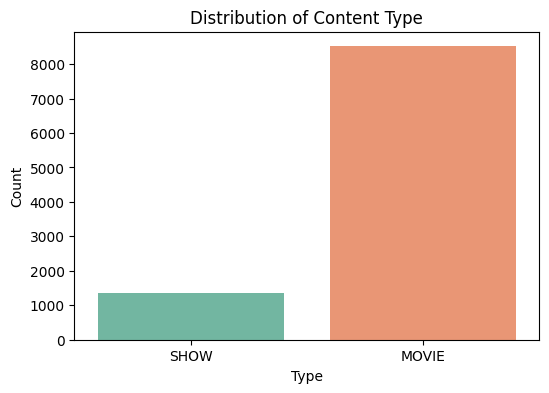

In [21]:
plt.figure(figsize=(6,4))
sns.countplot(data=merged_df , x='type', palette='Set2')
plt.title('Distribution of Content Type')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

"As you can see below we are further cleaning the genre data, we are doing so because if we don't then the genres will collap during the visualization of it. It will happen becuase there many genres in data who are assembles as one using commas, by removing the extras and arranging them as one we can plot a clear graph."

C:\Users\Bhumika chouhan\AppData\Local\Temp\ipykernel_4432\1829942732.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=genre_df, x='Genre', y='Count', palette='muted')


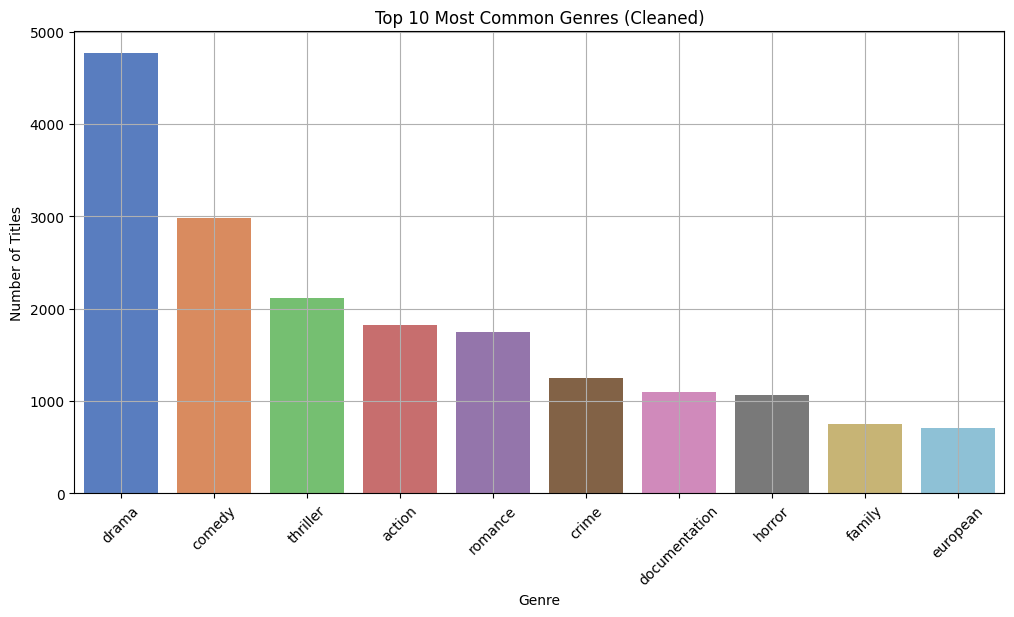

In [22]:
from collections import Counter
# here we are cleaning the genre category becuase when we directly visualize it same genres but with different punctuation appears as differently in the visualisation chart
genres_series = merged_df ['genres'].dropna()

cleaned_genres = []
for entry in genres_series:
    #so here we are removing commas, breackets and other extras
    entry = entry.replace('[', '').replace(']', '').replace("'", "").replace('"', '')

    genres = [genre.strip().lower() for genre in entry.split(',')]
    cleaned_genres.extend(genres)

genre_counts = Counter(cleaned_genres).most_common(10)

genre_df = pd.DataFrame(genre_counts, columns=['Genre', 'Count'])
plt.figure(figsize=(12, 6))
sns.barplot(data=genre_df, x='Genre', y='Count', palette='muted')
plt.title('Top 10 Most Common Genres (Cleaned)')
plt.xlabel('Genre')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


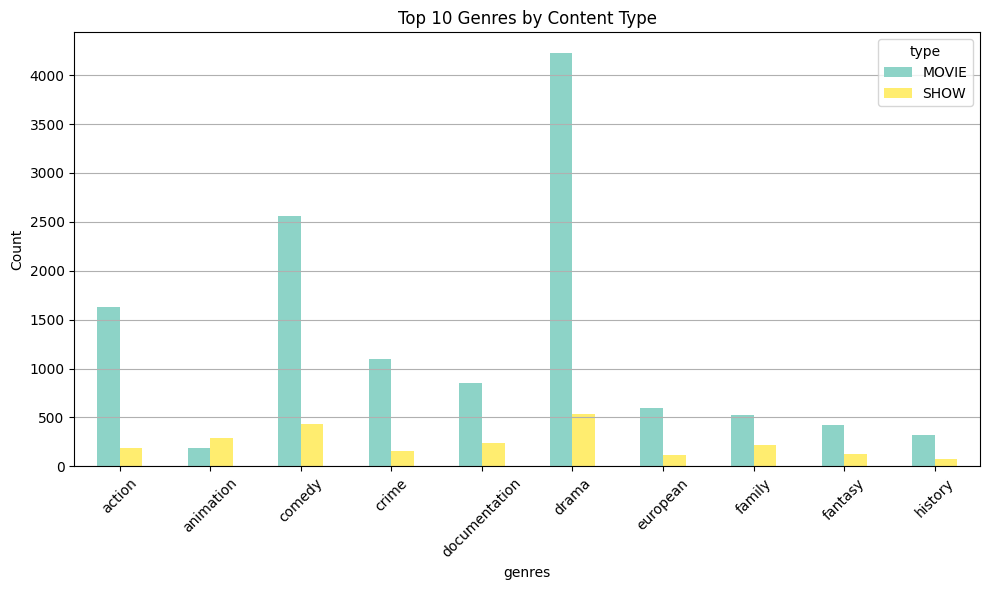

In [23]:
# First, explode the genres column
merged_df['genres'] = merged_df['genres'].fillna('[]')
merged_df['genres'] = merged_df['genres'].apply(lambda x: eval(x) if isinstance(x, str) else x)
merged_exploded = merged_df.explode('genres')

# Group and count
genre_type_counts = merged_exploded.groupby(['genres', 'type']).size().unstack().fillna(0)

# Plot
genre_type_counts.head(10).plot(kind='bar', figsize=(10, 6), colormap='Set3')
plt.title('Top 10 Genres by Content Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


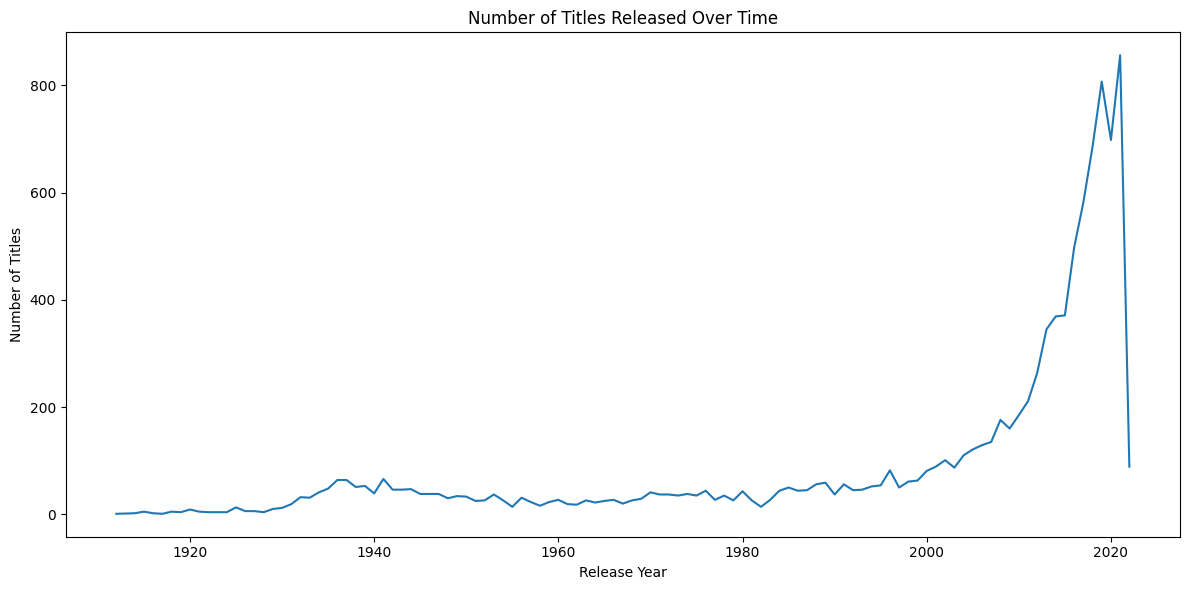

In [24]:

year_counts = merged_df['release_year'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x=year_counts.index, y=year_counts.values)
plt.title("Number of Titles Released Over Time")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.tight_layout()
plt.show()


In [25]:
from collections import Counter

country_series = merged_df['production_countries'].dropna()

cleaned_countries = []
for entry in country_series:
    entry = entry.replace('[', '').replace(']', '').replace("'", "").replace('"', '')
    countries = [country.strip() for country in entry.split(',')]
    cleaned_countries.extend(countries)

top_countries = Counter(cleaned_countries).most_common(10)


C:\Users\Bhumika chouhan\AppData\Local\Temp\ipykernel_4432\583356311.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(countries), y=list(counts), palette='coolwarm')


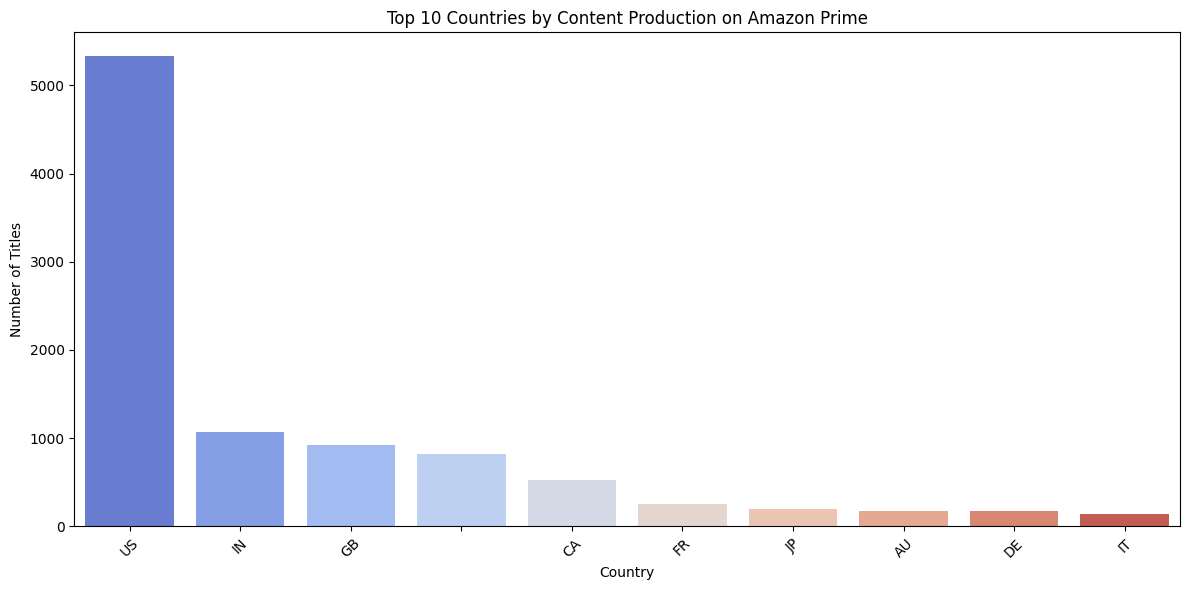

In [26]:
countries, counts = zip(*top_countries)

plt.figure(figsize=(12,6))
sns.barplot(x=list(countries), y=list(counts), palette='coolwarm')
plt.title("Top 10 Countries by Content Production on Amazon Prime")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

"Here we have used both a bar graph and a pie chart to plot the top 10 countries for content production in amazon prime and this provides us with different and cleared views."

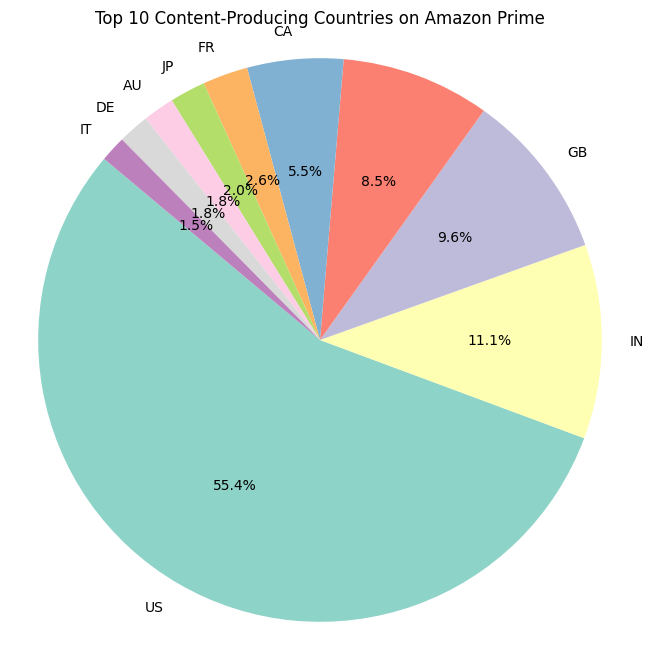

In [27]:
from collections import Counter
country_counts = Counter(cleaned_countries)
top_countries = country_counts.most_common(10)

# Separate names and values
countries, counts = zip(*top_countries)

# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(counts, labels=countries, autopct='%1.1f%%', startangle=140, colors=plt.cm.Set3.colors)
plt.title('Top 10 Content-Producing Countries on Amazon Prime')
plt.axis('equal')  # Equal aspect ratio ensures pie is circular.
plt.show()

In [29]:
print(merged_df[['title', 'imdb_score', 'tmdb_popularity', 'imdb_votes']].isnull().sum())

title                 0
imdb_score         1021
tmdb_popularity     547
imdb_votes         1031
dtype: int64


In [30]:
ratings_df = merged_df.dropna(subset=['imdb_score'])

C:\Users\Bhumika chouhan\AppData\Local\Temp\ipykernel_4432\1847922947.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_rated, x='imdb_score', y='title', palette='viridis')


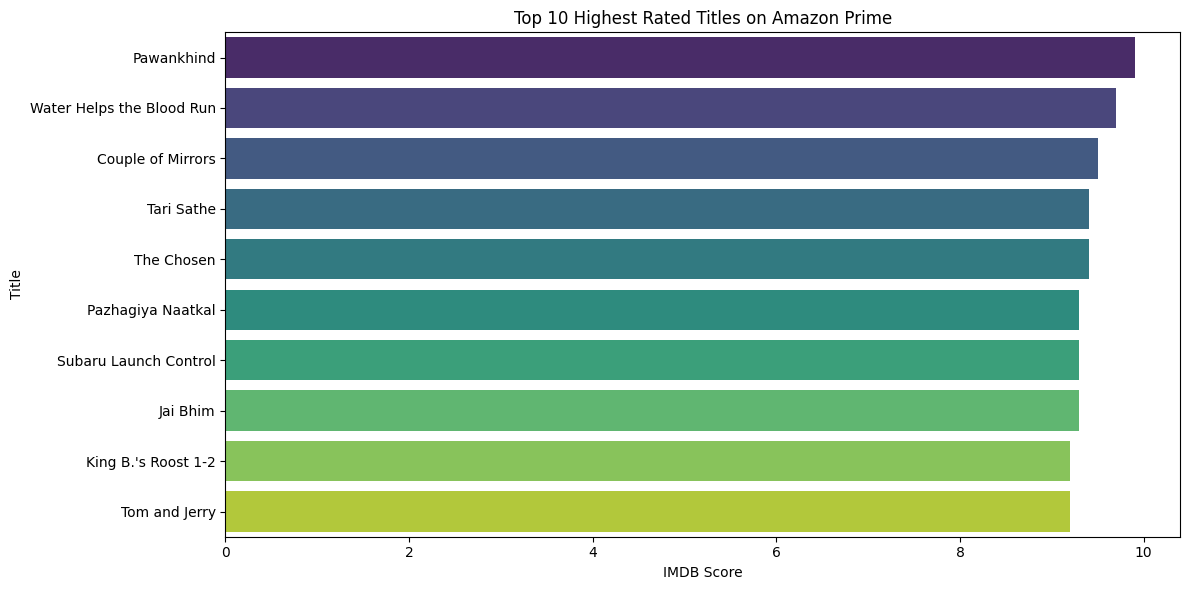

In [31]:
top_rated = ratings_df.sort_values(by='imdb_score', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_rated, x='imdb_score', y='title', palette='viridis')
plt.title('Top 10 Highest Rated Titles on Amazon Prime')
plt.xlabel('IMDB Score')
plt.ylabel('Title')
plt.tight_layout()
plt.show()

C:\Users\Bhumika chouhan\AppData\Local\Temp\ipykernel_4432\3116060241.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ratings_df, x='type', y='imdb_score', palette='Set2')


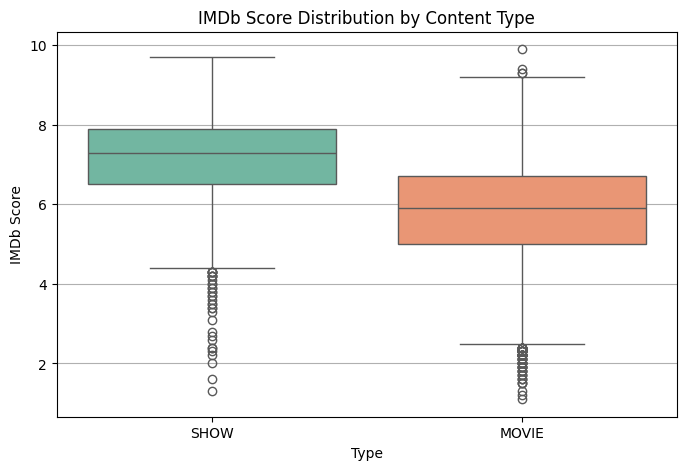

In [32]:

plt.figure(figsize=(8, 5))
sns.boxplot(data=ratings_df, x='type', y='imdb_score', palette='Set2')
plt.title('IMDb Score Distribution by Content Type')
plt.xlabel('Type')
plt.ylabel('IMDb Score')
plt.grid(axis='y')
plt.show()


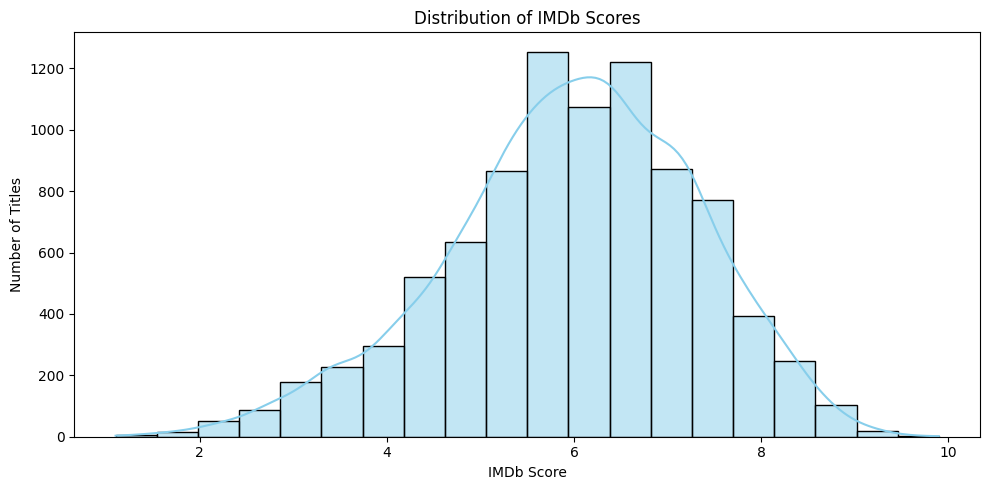

In [33]:
plt.figure(figsize=(10, 5))
sns.histplot(data=ratings_df, x='imdb_score', bins=20, kde=True, color='skyblue')
plt.title('Distribution of IMDb Scores')
plt.xlabel('IMDb Score')
plt.ylabel('Number of Titles')
plt.tight_layout()
plt.show()


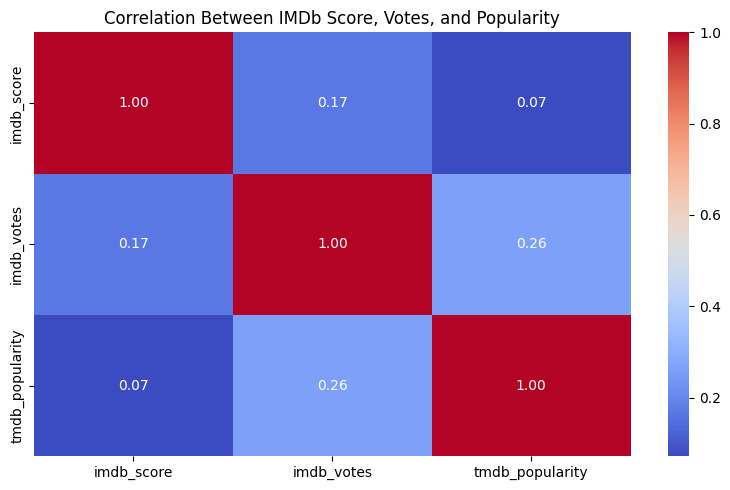

In [34]:
plt.figure(figsize=(8, 5))
sns.heatmap(ratings_df[['imdb_score', 'imdb_votes', 'tmdb_popularity']].corr(), 
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Between IMDb Score, Votes, and Popularity")
plt.tight_layout()
plt.show()


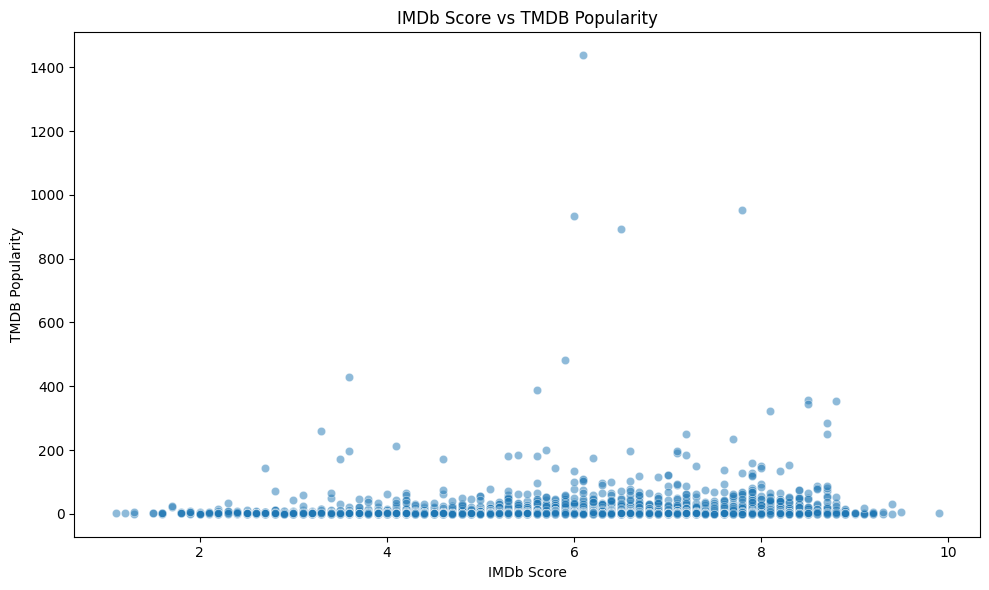

In [35]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=ratings_df, x='imdb_score', y='tmdb_popularity', alpha=0.5)
plt.title("IMDb Score vs TMDB Popularity")
plt.xlabel("IMDb Score")
plt.ylabel("TMDB Popularity")
plt.tight_layout()
plt.show()


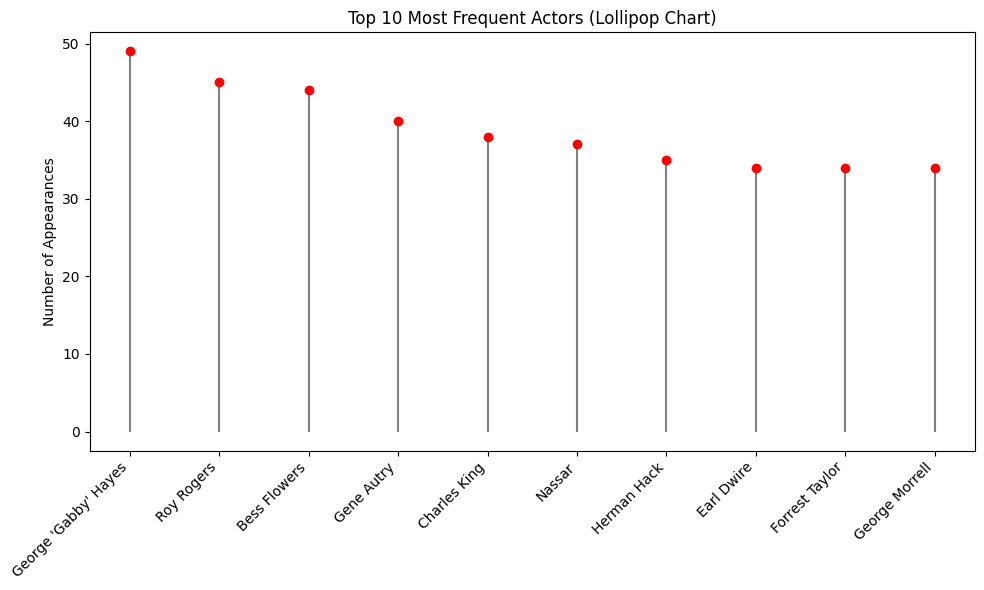

In [43]:
actor_df = merged_df[merged_df['role'] == 'ACTOR']

top_actors = Counter(actor_df['name']).most_common(10)
actor_names, appearances = zip(*top_actors)

plt.figure(figsize=(10, 6))
plt.stem(appearances, linefmt='gray', markerfmt='ro', basefmt=" ")
plt.xticks(range(len(actor_names)), actor_names, rotation=45, ha='right')
plt.ylabel('Number of Appearances')
plt.title('Top 10 Most Frequent Actors (Lollipop Chart)')
plt.tight_layout()
plt.show()


## 📊 Final Summary & Insights

- **Content Type**: Amazon Prime has a larger number of movies compared to TV shows.
- **Genres**: Drama, Comedy, and Action dominate the content library.
- **Trends Over Time**: A significant increase in content releases post-2015.
- **Regional Spread**: USA and India are the top content-producing countries.
- **Ratings**: Strong correlation found between IMDb votes and TMDB popularity.
- **Top Titles**: Highest-rated content is a mix of international and regional productions.
- **Cast Patterns**: A small group of actors appear frequently across multiple titles.
